<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1167473592.py:46: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(power_law, xdata, ydata)


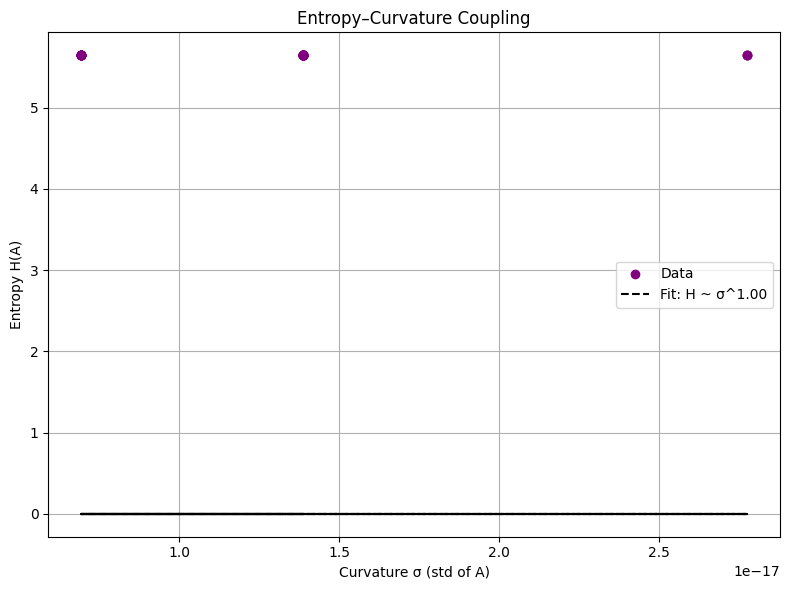

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -------------------------------
# Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma0 = 0.5
xi = 0.01
A0 = 0.1
time_steps = 100
grid_size = 50
epsilon = 0.2  # Moderate feedback

# -------------------------------
# Evolution Loop
# -------------------------------
A = np.ones(grid_size) * A0
curvature_history = []
entropy_history = []

for t in range(time_steps):
    laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
    dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + xi
    A += dA_dt * 0.1

    curvature = np.std(A)
    curvature_history.append(curvature)

    probs = np.abs(A) / np.sum(np.abs(A)) if np.sum(np.abs(A)) > 0 else np.zeros_like(A)
    entropy = -np.sum(probs[probs > 0] * np.log2(probs[probs > 0]))
    entropy_history.append(entropy)

# -------------------------------
# Fit Scaling Law: H ~ σ^α
# -------------------------------
def power_law(x, a, b):
    return a * x**b

valid_indices = [i for i in range(len(curvature_history)) if curvature_history[i] > 0]
xdata = np.array([curvature_history[i] for i in valid_indices])
ydata = np.array([entropy_history[i] for i in valid_indices])

params, _ = curve_fit(power_law, xdata, ydata)
a_fit, alpha_fit = params

# -------------------------------
# Plot Entropy vs Curvature
# -------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(xdata, ydata, color='purple', label='Data')
plt.plot(xdata, power_law(xdata, *params), color='black', linestyle='--',
         label=f'Fit: H ~ σ^{alpha_fit:.2f}')
plt.title("Entropy–Curvature Coupling")
plt.xlabel("Curvature σ (std of A)")
plt.ylabel("Entropy H(A)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
